# 📈 Stock Price Prediction Project

## Task 2: Short-Term Stock Price Prediction using Regression

### Project Overview
The goal of this task is to perform Time Series Forecasting by utilizing historical market data to predict a stock's next-day closing price.

### Core Requirements

- **Data Source:** Live historical data fetched via the yfinance API.
- **Features (X):** Daily Open, High, Low, and Volume metrics.
- **Target (y):** The Next Day's Closing Price.
- **Model:** Implementation of a Linear Regression or Random Forest algorithm.
- **Evaluation:** Graphical comparison of predicted vs. actual price movements.

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [9]:
df = yf.download("TSLA", start="2023-01-01", end="2025-01-01")
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

[*********************100%***********************]  1 of 1 completed


In [10]:
df['Next_Close'] = df['Close'].shift(-1)
df = df.dropna()
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Next_Close']

In [11]:
# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Initialize and train Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

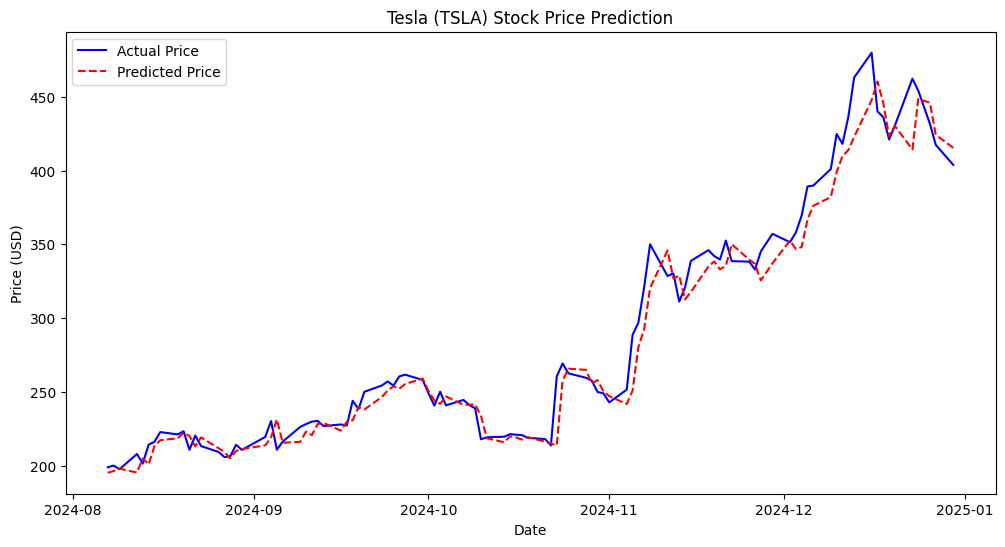

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual Price', color='blue')
plt.plot(y_test.index, predictions, label='Predicted Price', color='red', linestyle='--')
plt.title('Tesla (TSLA) Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()